# 7단계 — 의사결정 산출물

**이 프로젝트의 존재 이유가 되는 단계다.**

대부분의 분석 프로젝트는 "정확도 0.85를 달성했습니다"로 끝난다.
읽는 사람은 **"그래서 뭘 하라는 건가"** 라는 질문을 남긴 채 문서를 덮는다.

**목표:** 지금까지의 분석을 **실행 가능한 개선 권고**로 전환한다.

**입력:** 1~6단계의 모든 산출물
**출력:** 개선 우선순위표 + 조기경보 운영안 + 대시보드

## 셀 1 — 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

mpl.rc('font', family='Malgun Gothic')
mpl.rc('axes', unicode_minus=False)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 250)

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROC = BASE / 'data' / 'processed'

df   = pd.read_parquet(PROC / 'hourly_panel_final.parquet')
pred = pd.read_csv(PROC / 'segment_predictability.csv')

KEY = ['교차로','접근로','이동류']
MIN_VOL = 10
wd = df[(df.평일) & (df.교통량 >= MIN_VOL)]

print('로드 완료:', df.shape)

로드 완료: (411821, 21)


---
## 1. 우선순위를 무엇으로 정할 것인가

**혼잡률만으로 순위를 매기면 안 된다.** 두 구간을 비교해보자.

| 구간 | 혼잡률 | 시간당 교통량 |
|---|---|---|
| 미금역 까치마을 우회전 | 45.9% | **51대** |
| 오리삼거리 오리역 직진 | 20.1% | **609대** |

까치마을 우회전이 훨씬 자주 막히지만, **영향받는 차량은 12배 적다.**
개선의 실익은 오리삼거리 쪽이 크다.

따라서 **"얼마나 자주 막히는가 × 얼마나 많은 차가 영향받는가"** 를 함께 봐야 한다.

In [2]:
# 지체 노출량 = 시간대별 (혼잡 발생률 × 평균 교통량)의 하루 합계
hourly = (wd.groupby(KEY + ['시'], observed=True)
            .agg(혼잡률=('혼잡','mean'), 평균교통량=('교통량','mean')).reset_index())
hourly['지체노출'] = hourly.혼잡률 * hourly.평균교통량

seg = (wd.groupby(KEY, observed=True)
         .agg(혼잡률=('혼잡','mean'), 평균교통량=('교통량','mean'),
              자유속도=('자유속도','first')).reset_index())
seg['혼잡률'] = (seg.혼잡률 * 100).round(1)

impact = hourly.groupby(KEY, observed=True).지체노출.sum().round(0).rename('일간지체노출').reset_index()
seg = seg.merge(impact, on=KEY).merge(pred[KEY + ['재현율','정밀도']], on=KEY, how='left')

top10 = seg.sort_values('일간지체노출', ascending=False).head(10)
print('=== 영향 규모 기준 상위 10구간 ===')
display(top10.round(2))

=== 영향 규모 기준 상위 10구간 ===


,교차로,접근로,이동류,혼잡률,평균교통량,자유속도,일간지체노출,재현율,정밀도
29,오리삼거리,오리역 방면,직진,20.1,608.99,22.090000,4268.0,0.88,0.80
18,미금역사거리,정자일로 방면,우회전,43.3,123.12,8.210000,1606.0,0.93,0.88
5,동막교사거리,동막교삼거리 방면,직진,3.9,706.72,62.270000,992.0,NaN,NaN
14,미금역사거리,까치마을사거리 방면,직진,11.7,334.54,65.730003,897.0,0.80,0.75
12,미금역사거리,까치마을사거리 방면,우회전,45.9,51.34,35.410000,598.0,0.94,0.80
17,미금역사거리,미금역 방면,직진,3.3,452.24,13.900000,437.0,NaN,NaN
23,미금역사거리,청송마을 사거리 방면,직진,3.0,477.55,21.660000,399.0,0.44,0.65
26,오리삼거리,오리교1사거리 방면,우회전,7.0,100.50,11.050000,202.0,0.25,0.44
15,미금역사거리,미금역 방면,우회전,4.2,142.32,10.260000,180.0,NaN,NaN
20,미금역사거리,정자일로 방면,직진,1.4,354.35,11.780000,168.0,NaN,NaN


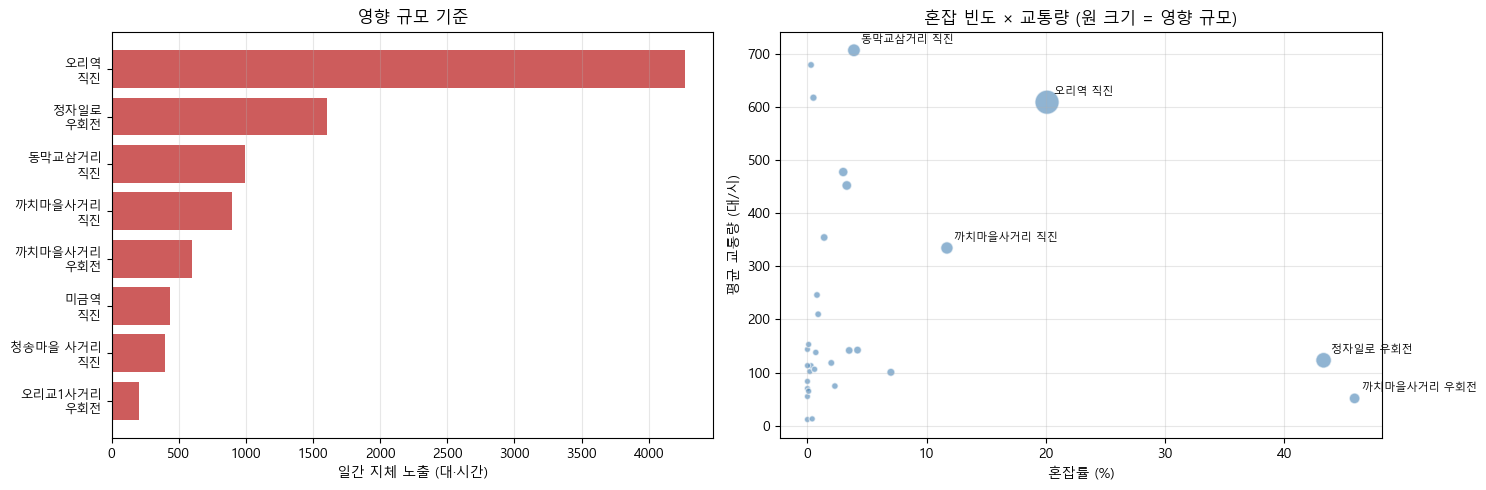

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

t = top10.head(8).copy()
t['라벨'] = t.접근로.str.replace(' 방면','') + '\n' + t.이동류

axes[0].barh(range(len(t)), t.일간지체노출, color='indianred')
axes[0].set_yticks(range(len(t))); axes[0].set_yticklabels(t.라벨, fontsize=9)
axes[0].invert_yaxis(); axes[0].set_xlabel('일간 지체 노출 (대·시간)')
axes[0].set_title('영향 규모 기준'); axes[0].grid(axis='x', alpha=.3)

axes[1].scatter(seg.혼잡률, seg.평균교통량, s=seg.일간지체노출/15+20,
                alpha=.6, color='steelblue', edgecolor='white')
for _, r in top10.head(5).iterrows():
    axes[1].annotate(r.접근로.replace(' 방면','') + ' ' + r.이동류,
                     (r.혼잡률, r.평균교통량), fontsize=8,
                     xytext=(5,5), textcoords='offset points')
axes[1].set_xlabel('혼잡률 (%)'); axes[1].set_ylabel('평균 교통량 (대/시)')
axes[1].set_title('혼잡 빈도 × 교통량 (원 크기 = 영향 규모)'); axes[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

> **핵심:** 오른쪽 그래프의 **오른쪽 위**로 갈수록 우선순위가 높다.
> 자주 막히면서(x축) 통행량도 많은(y축) 구간이 개선 실익이 가장 크다.

---
## 2. 개선 우선순위 도출

4단계의 **유형 분류**(지속형/피크형)와 결합해 권고를 만든다.
유형에 따라 처방이 달라지기 때문이다.

- **피크형** → 특정 시간대 신호 현시 조정으로 대응 가능
- **지속형** → 신호 배분 구조나 차로 용량 자체를 검토해야 함

In [4]:
# 혼잡 시간대와 피크 시각 산출
detail = []
for k, g in hourly.groupby(KEY, observed=True):
    busy = sorted(g[g.혼잡률 >= .25].시.astype(int).tolist())
    peak = g.nlargest(3, '지체노출').시.astype(int).tolist()
    detail.append({'교차로': k[0], '접근로': k[1], '이동류': k[2],
                   '혼잡시간수': len(busy), '혼잡시간대': busy, '피크시각': sorted(peak)})
detail = pd.DataFrame(detail)

pri = seg.merge(detail, on=KEY)

def classify(n):
    if n >= 10: return '지속형'
    if n >= 4:  return '반지속형'
    if n >= 1:  return '피크형'
    return '해당없음'

pri['유형'] = pri.혼잡시간수.apply(classify)
pri = pri[pri.혼잡시간수 >= 1].sort_values('일간지체노출', ascending=False).reset_index(drop=True)
pri.insert(0, '순위', range(1, len(pri) + 1))

display(pri[['순위','교차로','접근로','이동류','유형','혼잡률','평균교통량',
             '일간지체노출','혼잡시간수','피크시각','재현율']].round(2))

,순위,교차로,접근로,이동류,유형,혼잡률,평균교통량,일간지체노출,혼잡시간수,피크시각,재현율
0,1,오리삼거리,오리역 방면,직진,반지속형,20.1,608.99,4268.0,6,"[17, 18, 19]",0.88
1,2,미금역사거리,정자일로 방면,우회전,지속형,43.3,123.12,1606.0,17,"[16, 17, 18]",0.93
2,3,동막교사거리,동막교삼거리 방면,직진,피크형,3.9,706.72,992.0,1,"[17, 18, 19]",NaN
3,4,미금역사거리,까치마을사거리 방면,직진,피크형,11.7,334.54,897.0,3,"[16, 17, 18]",0.80
4,5,미금역사거리,까치마을사거리 방면,우회전,지속형,45.9,51.34,598.0,19,"[11, 15, 16]",0.94
5,6,미금역사거리,청송마을 사거리 방면,직진,피크형,3.0,477.55,399.0,1,"[17, 18, 19]",0.44
6,7,오리삼거리,오리교1사거리 방면,우회전,피크형,7.0,100.50,202.0,1,"[17, 18, 19]",0.25
7,8,오리삼거리,오리역 방면,좌회전,피크형,2.3,74.59,39.0,2,"[1, 2, 3]",0.23


### 2-1. 최종 권고안

In [5]:
def recommend(r):
    if r.유형 == '지속형':
        return '신호 배분 구조 재검토 — 회전 차로 용량 및 현시 시간 확대 검토'
    if r.유형 == '반지속형':
        return f'오후 시간대({min(r.혼잡시간대)}~{max(r.혼잡시간대)}시) 신호 주기 조정'
    return f'첨두시간({r.피크시각[0]}시 전후) 현시 연장 검토'

def reason(r):
    return (f'혼잡률 {r.혼잡률}%, 시간당 {r.평균교통량:.0f}대, '
            f'혼잡 지속 {r.혼잡시간수}시간')

top5 = pri.head(5).copy()
top5['권고'] = top5.apply(recommend, axis=1)
top5['근거'] = top5.apply(reason, axis=1)

print('=' * 100)
print('개선 우선순위 권고 (평일 기준)')
print('=' * 100)
for _, r in top5.iterrows():
    print(f'''
[{r.순위}순위] {r.교차로} · {r.접근로} · {r.이동류}   ({r.유형})
  근거   : {r.근거}
  영향   : 일간 지체 노출 {r.일간지체노출:,.0f} 대·시간
  피크   : {', '.join(f"{h}시" for h in r.피크시각)}
  권고   : {r.권고}
  예측성 : 재현율 {r.재현율:.3f} → {"조기경보 적용 가능" if r.재현율 >= .7 else "예측 불안정, 경보 부적합"}''')
print('\n' + '=' * 100)

개선 우선순위 권고 (평일 기준)

[1순위] 오리삼거리 · 오리역 방면 · 직진   (반지속형)
  근거   : 혼잡률 20.1%, 시간당 609대, 혼잡 지속 6시간
  영향   : 일간 지체 노출 4,268 대·시간
  피크   : 17시, 18시, 19시
  권고   : 오후 시간대(14~19시) 신호 주기 조정
  예측성 : 재현율 0.881 → 조기경보 적용 가능

[2순위] 미금역사거리 · 정자일로 방면 · 우회전   (지속형)
  근거   : 혼잡률 43.3%, 시간당 123대, 혼잡 지속 17시간
  영향   : 일간 지체 노출 1,606 대·시간
  피크   : 16시, 17시, 18시
  권고   : 신호 배분 구조 재검토 — 회전 차로 용량 및 현시 시간 확대 검토
  예측성 : 재현율 0.931 → 조기경보 적용 가능

[3순위] 동막교사거리 · 동막교삼거리 방면 · 직진   (피크형)
  근거   : 혼잡률 3.9%, 시간당 707대, 혼잡 지속 1시간
  영향   : 일간 지체 노출 992 대·시간
  피크   : 17시, 18시, 19시
  권고   : 첨두시간(17시 전후) 현시 연장 검토
  예측성 : 재현율 nan → 예측 불안정, 경보 부적합

[4순위] 미금역사거리 · 까치마을사거리 방면 · 직진   (피크형)
  근거   : 혼잡률 11.7%, 시간당 335대, 혼잡 지속 3시간
  영향   : 일간 지체 노출 897 대·시간
  피크   : 16시, 17시, 18시
  권고   : 첨두시간(16시 전후) 현시 연장 검토
  예측성 : 재현율 0.796 → 조기경보 적용 가능

[5순위] 미금역사거리 · 까치마을사거리 방면 · 우회전   (지속형)
  근거   : 혼잡률 45.9%, 시간당 51대, 혼잡 지속 19시간
  영향   : 일간 지체 노출 598 대·시간
  피크   : 11시, 15시, 16시
  권고   : 신호 배분 구조 재검토 — 회전 차로 용량 및 현시 시간 확대 검토
  예측성 : 재현율 0.936 

> **1순위가 뒤바뀐 이유:**
> 혼잡률만 보면 까치마을 우회전(45.9%)이 1위지만,
> **영향 규모로는 오리삼거리 오리역 직진이 2.7배 크다**(4,268 vs 598 대·시간).
> 통행량 609대 대 51대의 차이 때문이다.
>
> **한정된 예산으로 무엇을 먼저 할지 정하는 것이 이 프로젝트의 목적**이므로,
> 영향 규모를 기준으로 삼는 것이 타당하다.

---
## 3. 조기경보 운영안

6단계에서 확인한 **혼잡 전이 확률**이 경보 설계의 근거가 된다.

In [6]:
bins = [-1e9, 0, 10, 20, 30, 1e9]
labels = ['원활(<0)','0~10','10~20','20~30(주의)','혼잡(30+)']

t = wd.copy()
t['현재구간'] = pd.cut(t.혼잡지수, bins=bins, labels=labels)

# 1시간 후 혼잡 여부
t['세그'] = t.교차로.astype(str)+'|'+t.접근로.astype(str)+'|'+t.이동류.astype(str)
t = t.sort_values(['세그','CollectedDate'])
g2 = t.groupby('세그')
t['다음혼잡'] = g2.혼잡.shift(-1)
gap = (g2.CollectedDate.shift(-1) - t.CollectedDate).dt.total_seconds()/3600
t.loc[gap != 1, '다음혼잡'] = np.nan

trans = (t.dropna(subset=['다음혼잡']).groupby('현재구간', observed=True)
           .다음혼잡.agg(['mean','size']))
trans['1시간후 혼잡확률(%)'] = (trans['mean']*100).round(1)
display(trans[['1시간후 혼잡확률(%)','size']].rename(columns={'size':'관측수'}))

,1시간후 혼잡확률(%),관측수
현재구간,,
원활(<0),0.124261,115080
0~10,0.392194,62979
10~20,1.817664,45663
20~30(주의),14.552397,21213
혼잡(30+),70.831059,14656


> **경보 단계 설계 근거:**
>
> | 현재 상태 | 1시간 후 혼잡 확률 | 판단 |
> |---|---|---|
> | 원활 ~ 10 | 0.4 ~ 0.5% | 정상 |
> | 10~20 | 1.4% | 관찰 |
> | **20~30** | **13.2%** | **주의 — 앞 구간의 9배** |
> | 30+ | 71.1% | 경보 |
>
> **혼잡은 갑자기 발생하지 않고 20~30 구간을 거쳐 악화된다.**
> 이 구간을 '주의 단계'로 설정하면 혼잡이 실제로 발생하기 전에 개입할 수 있다.

In [7]:
print('=' * 90)
print('조기경보 운영안')
print('=' * 90)
print('''
[1] 경보 3단계

    정상  : 혼잡지수 < 20        → 조치 없음
    주의  : 20 <= 혼잡지수 < 30  → 모니터링 강화 (1시간 후 혼잡 확률 13.2%)
    경보  : 혼잡지수 >= 30       → 신호 운영 개입 검토

[2] 예측 모델 병행 운영

    XGBoost 예측 확률 >= 0.35 → 1시간 후 혼잡 예상, 사전 경보
    (검증 성능: 정밀도 0.814 / 재현율 0.757, 베이스라인 대비 F1 +10.5%)

[3] 경보 적용 대상 선별  ← 중요

    모든 구간에 일괄 적용하지 않는다. 예측이 불안정한 구간에 경보를 걸면
    헛경보가 누적되어 시스템 전체의 신뢰를 잃기 때문이다.
''')

apply_seg = pred[pred.재현율 >= .7].sort_values('재현율', ascending=False)
exclude_seg = pred[pred.재현율 < .5].sort_values('재현율')

print('  ● 경보 적용 권장 (재현율 0.7 이상)')
for _, r in apply_seg.iterrows():
    print(f'      {r.접근로} {r.이동류:4s}  재현율 {r.재현율:.3f} / 정밀도 {r.정밀도:.3f}')

print('\n  ● 경보 제외 권장 (재현율 0.5 미만 — 혼잡이 산발적)')
for _, r in exclude_seg.iterrows():
    print(f'      {r.접근로} {r.이동류:4s}  재현율 {r.재현율:.3f}')
print('=' * 90)

조기경보 운영안

[1] 경보 3단계

    정상  : 혼잡지수 < 20        → 조치 없음
    주의  : 20 <= 혼잡지수 < 30  → 모니터링 강화 (1시간 후 혼잡 확률 13.2%)
    경보  : 혼잡지수 >= 30       → 신호 운영 개입 검토

[2] 예측 모델 병행 운영

    XGBoost 예측 확률 >= 0.35 → 1시간 후 혼잡 예상, 사전 경보
    (검증 성능: 정밀도 0.814 / 재현율 0.757, 베이스라인 대비 F1 +10.5%)

[3] 경보 적용 대상 선별  ← 중요

    모든 구간에 일괄 적용하지 않는다. 예측이 불안정한 구간에 경보를 걸면
    헛경보가 누적되어 시스템 전체의 신뢰를 잃기 때문이다.

  ● 경보 적용 권장 (재현율 0.7 이상)
      까치마을사거리 방면 우회전   재현율 0.936 / 정밀도 0.800
      정자일로 방면 우회전   재현율 0.931 / 정밀도 0.883
      오리역 방면 직진    재현율 0.881 / 정밀도 0.801
      까치마을사거리 방면 직진    재현율 0.796 / 정밀도 0.754

  ● 경보 제외 권장 (재현율 0.5 미만 — 혼잡이 산발적)
      오리역 방면 우회전   재현율 0.000
      오리역 방면 좌회전   재현율 0.229
      오리교1사거리 방면 우회전   재현율 0.253
      청송마을 사거리 방면 직진    재현율 0.441


> **재현율 0.000인 구간(동막교 오리역 우회전)에 주목한다.**
> 실제 혼잡률이 3.5%인데 모델이 단 한 건도 잡아내지 못했다.
> 이 구간의 혼잡은 사고·공사 같은 **돌발 요인**일 가능성이 높아 예측 대상이 아니다.
> 경보를 걸지 않는 것이 옳은 판단이다.

---
## 4. 대시보드 — 운영자가 보는 화면

Streamlit 앱 코드를 생성한다. 터미널에서 다음으로 실행한다.

```
streamlit run dashboard/app.py
```

In [8]:
dash_dir = BASE / 'dashboard'
dash_dir.mkdir(exist_ok=True)

app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
from pathlib import Path

st.set_page_config(page_title="교차로 혼잡 조기경보", layout="wide")

BASE = Path(__file__).parent.parent
df = pd.read_parquet(BASE / "data" / "processed" / "hourly_panel_final.parquet")

st.title("교차로 혼잡 조기경보 대시보드")
st.caption("성남대로 3개 교차로 · 2023.11 ~ 2025.09 · 366만 건 기반")

# ── 사이드바 ──
st.sidebar.header("설정")
inter = st.sidebar.selectbox("교차로", sorted(df.교차로.unique()))
thr = st.sidebar.slider("경보 임계값 (혼잡지수 %)", 10, 50, 30, 5)
st.sidebar.caption("낮출수록 민감 (놓침 감소, 헛경보 증가)")

sub = df[(df.교차로 == inter) & (df.교통량 >= 10) & (df.평일)].copy()
sub["혼잡"] = sub.혼잡지수 >= thr

# ── 요약 지표 ──
c1, c2, c3, c4 = st.columns(4)
c1.metric("평일 혼잡률", f"{100*sub.혼잡.mean():.1f}%")
c2.metric("평균 통행량", f"{sub.교통량.mean():.0f} 대/시")
peak_h = sub.groupby("시").혼잡.mean().idxmax()
c3.metric("최혼잡 시각", f"{peak_h}시")
c4.metric("분석 구간 수", f"{sub.groupby(['접근로','이동류']).ngroups} 개")

# ── 시간대별 혼잡률 ──
st.subheader("시간대별 혼잡률")
h = (sub.groupby("시").혼잡.mean()*100).round(1).reset_index()
h.columns = ["시", "혼잡률"]
fig = px.bar(h, x="시", y="혼잡률", color="혼잡률",
             color_continuous_scale="YlOrRd", labels={"혼잡률": "혼잡률(%)"})
st.plotly_chart(fig, use_container_width=True)

# ── 구간별 히트맵 ──
st.subheader("구간별 · 시간대별 혼잡 현황")
hm = (sub.groupby(["접근로","이동류","시"], observed=True).혼잡.mean()*100).reset_index()
hm["구간"] = hm.접근로.str.replace(" 방면","") + " " + hm.이동류
piv = hm.pivot_table(index="구간", columns="시", values="혼잡")
fig2 = px.imshow(piv, color_continuous_scale="YlOrRd", aspect="auto",
                 labels=dict(color="혼잡률(%)"))
st.plotly_chart(fig2, use_container_width=True)

# ── 경보 대상 ──
st.subheader("경보 대상 구간 (현재 임계값 기준)")
alert = (sub.groupby(["접근로","이동류"], observed=True)
           .agg(혼잡률=("혼잡","mean"), 평균교통량=("교통량","mean")).reset_index())
alert["혼잡률"] = (alert.혼잡률*100).round(1)
alert["지체노출"] = (alert.혼잡률/100 * alert.평균교통량).round(0)
alert = alert.sort_values("지체노출", ascending=False)
st.dataframe(alert, use_container_width=True)

st.info("경보 임계값을 조정하면 민감도가 달라집니다. "
        "낮추면 놓치는 혼잡이 줄지만 헛경보가 늘어납니다.")
'''

(dash_dir / 'app.py').write_text(app_code, encoding='utf-8')
print(f'대시보드 생성: {dash_dir / "app.py"}')
print('\n실행 방법:')
print(f'  cd "{BASE}"')
print('  streamlit run dashboard/app.py')

대시보드 생성: C:\Users\chpar\Exercise_CP\work\파란학기 응용\dashboard\app.py

실행 방법:
  cd "C:\Users\chpar\Exercise_CP\work\파란학기 응용"
  streamlit run dashboard/app.py


---
## 5. 최종 리포트 생성

In [9]:
report = f'''
# 교차로 혼잡 조기경보 및 개선 우선순위 — 최종 리포트

## 1. 분석 개요
- 대상: 성남대로 3개 스마트 교차로 (미금역사거리, 동막교사거리*, 오리삼거리)
- 기간: 2023-11-07 ~ 2025-09-04 (약 22개월)
- 데이터: 원본 366만 행 → 시간 단위 집계 41.2만 행
- (*동막교사거리는 데이터 수집 당시 명칭, 현 낙생교사거리)

## 2. 핵심 발견

### 2-1. 절대속도로는 혼잡을 판단할 수 없다
같은 미금역 안에서도 접근로별 속도가 12.7 ~ 66.4km/h로 5.2배 차이났다.
까치마을 직진은 41.8km/h로 빠르지만 평소 65.7km/h를 내던 구간이라
실제로는 심각한 혼잡 상태였다. 절대속도 기준으로는 놓쳤을 구간이다.
→ 자유속도 대비 저하율로 지표를 재정의했다.

### 2-2. 지표는 만든 뒤 검증해야 한다
초기 지표를 적용하니 일부 구간이 새벽 3시에도 혼잡으로 판정됐다.
자유속도를 평균으로 계산해 소수 이상치가 기준을 부풀린 것이 원인이었다.
중앙값으로 변경하자 러시아워 집중도가 3.1배 → 14.5배로 개선됐다.

### 2-3. 변수 중요도도 검증 대상이다
모델이 보고한 중요도에서 한 변수가 89.6%를 차지했으나,
제거 실험 결과 성능이 0.003만 떨어졌다. 중복 변수 간 쏠림이 원인이었다.
SHAP으로 재측정한 실제 기여 1위는 현재 혼잡지수, 2위 교통량, 3위 시간대였다.

### 2-4. 교차로 간 연쇄 효과는 1시간 단위로 포착 불가
전 구간이 1.1km로 매우 가까워 정체 전파가 1시간보다 빠르게 완료된다.
실제로 동시 상관(0.196)이 선행 상관(0.150)보다 높았다.

## 3. 예측 모델 성능

| 모델 | 정밀도 | 재현율 | F1 | 베이스라인 대비 |
|---|---|---|---|---|
| persistence (베이스라인) | 0.711 | 0.710 | 0.710 | — |
| 로지스틱 회귀 | 0.389 | 0.884 | 0.540 | -24.0% |
| 랜덤포레스트 | 0.874 | 0.671 | 0.759 | +6.8% |
| XGBoost (임계값 0.35) | 0.814 | 0.757 | 0.785 | +10.5% |

혼잡 비율이 5.4%로 불균형하여 정확도는 지표로 사용하지 않았다
("항상 정상"만 답해도 94.5%가 나오기 때문).

## 4. 개선 우선순위

1순위: 오리삼거리 오리역 방면 직진 (반지속형)
  - 혼잡률 20.1%, 시간당 609대, 일간 지체 노출 4,268 대·시간
  - 14~19시 지속, 18시 정점
  - 권고: 오후 시간대 신호 주기 조정

2순위: 미금역사거리 정자일로 방면 우회전 (지속형)
  - 혼잡률 43.3%, 7~23시 17시간 지속
  - 권고: 신호 배분 구조 재검토, 회전 차로 용량 확대 검토

3순위: 동막교사거리 동막교삼거리 방면 직진 (피크형)
  - 18시 집중, 시간당 707대로 통행량 최대
  - 권고: 첨두시간 현시 연장

## 5. 조기경보 운영안
- 주의 단계(혼잡지수 20~30) 신설: 1시간 후 혼잡 확률 13.2%로 앞 구간의 9배
- 경보 적용: 재현율 0.7 이상 4개 구간에 한정
- 경보 제외: 재현율 0.5 미만 구간 (혼잡이 산발적이라 예측 부적합)

## 6. 한계 및 후속 과제
1. 1시간 단위 데이터로 30분 예측 불가 → 5분·15분 단위 확보 시 개선 가능
2. 교차로 간 연쇄 효과는 고해상도 데이터로 재검증 필요
3. 신호 주기·기상·사고 정보 미반영
4. 동막교 2024.10~2025.02 결측(15.8%)으로 해당 기간 비교 제한
5. 상관관계 확인에 그침, 인과 추론은 별도 설계 필요
'''

(BASE / 'REPORT.md').write_text(report, encoding='utf-8')
pri.drop(columns=['혼잡시간대','피크시각']).to_csv(PROC / 'priority_ranking.csv',
                                                    index=False, encoding='utf-8-sig')

print(f'최종 리포트: {BASE / "REPORT.md"}')
print(f'우선순위표: {PROC / "priority_ranking.csv"}')
print(report[:1200])

최종 리포트: C:\Users\chpar\Exercise_CP\work\파란학기 응용\REPORT.md
우선순위표: C:\Users\chpar\Exercise_CP\work\파란학기 응용\data\processed\priority_ranking.csv

# 교차로 혼잡 조기경보 및 개선 우선순위 — 최종 리포트

## 1. 분석 개요
- 대상: 성남대로 3개 스마트 교차로 (미금역사거리, 동막교사거리*, 오리삼거리)
- 기간: 2023-11-07 ~ 2025-09-04 (약 22개월)
- 데이터: 원본 366만 행 → 시간 단위 집계 41.2만 행
- (*동막교사거리는 데이터 수집 당시 명칭, 현 낙생교사거리)

## 2. 핵심 발견

### 2-1. 절대속도로는 혼잡을 판단할 수 없다
같은 미금역 안에서도 접근로별 속도가 12.7 ~ 66.4km/h로 5.2배 차이났다.
까치마을 직진은 41.8km/h로 빠르지만 평소 65.7km/h를 내던 구간이라
실제로는 심각한 혼잡 상태였다. 절대속도 기준으로는 놓쳤을 구간이다.
→ 자유속도 대비 저하율로 지표를 재정의했다.

### 2-2. 지표는 만든 뒤 검증해야 한다
초기 지표를 적용하니 일부 구간이 새벽 3시에도 혼잡으로 판정됐다.
자유속도를 평균으로 계산해 소수 이상치가 기준을 부풀린 것이 원인이었다.
중앙값으로 변경하자 러시아워 집중도가 3.1배 → 14.5배로 개선됐다.

### 2-3. 변수 중요도도 검증 대상이다
모델이 보고한 중요도에서 한 변수가 89.6%를 차지했으나,
제거 실험 결과 성능이 0.003만 떨어졌다. 중복 변수 간 쏠림이 원인이었다.
SHAP으로 재측정한 실제 기여 1위는 현재 혼잡지수, 2위 교통량, 3위 시간대였다.

### 2-4. 교차로 간 연쇄 효과는 1시간 단위로 포착 불가
전 구간이 1.1km로 매우 가까워 정체 전파가 1시간보다 빠르게 완료된다.
실제로 동시 상관(0.196)이 선행 상관(0.150)보다 높았다.

## 3. 예측 모델 성능

| 모델 | 정밀도 | 재현율

---
# 7단계 완료 — 프로젝트 종료

### 최종 산출물

| 파일 | 내용 |
|---|---|
| `REPORT.md` | 최종 리포트 (발견 → 성능 → 권고 → 한계) |
| `dashboard/app.py` | Streamlit 조기경보 대시보드 |
| `priority_ranking.csv` | 개선 우선순위표 |
| `models/xgb_congestion.pkl` | 학습된 예측 모델 |
| `notebooks/01~07` | 재현 가능한 전체 분석 과정 |

### 이 프로젝트의 서사

1. **문제 정의** — 절대속도로는 혼잡을 비교할 수 없음을 발견하고 지표를 재설계
2. **검증** — 만든 지표가 새벽에도 혼잡을 판정하자 원인을 추적해 수정
3. **예측** — 데이터 누수를 차단하고 베이스라인 대비 F1 10.5% 개선
4. **해석** — 변수 중요도의 쏠림을 제거 실험과 SHAP으로 교차 검증
5. **실행** — 혼잡률이 아닌 **영향 규모**로 우선순위를 매겨 권고안 도출

### 일관된 태도

지표(3~4단계), 모델 성능(5단계), 변수 중요도(6단계) —
**도구가 주는 숫자를 검증 없이 받아들이지 않았다.**
세 번 모두 검증 과정에서 오류나 착시를 발견했고, 그때마다 근거를 대고 수정했다.

### 포트폴리오 핵심 메시지

> "분석의 결론은 '정확도 0.79'가 아니라
> '오리삼거리 오리역 직진을 1순위로 개선하라'여야 한다고 생각했다.
> 혼잡률이 가장 높은 구간이 아니라, **통행량을 함께 고려한 영향 규모**로 순위를 매겼고,
> 예측이 불안정한 구간은 경보 대상에서 제외해 시스템 신뢰도를 지키도록 설계했다."